<a href="https://colab.research.google.com/github/N-Acil/2022-21-03-Birmingham/blob/gh-pages/NCEO_AGB_Africa_Change_2015_2021_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import ee
ee.Authenticate()
ee.Initialize(project='ee-nacil')

Mounted at /content/drive


In [ ]:
!pip install cartopy
!pip install matplotlib-scalebar
!pip install rasterio
!pip install matplotlib-map-utils
!pip install cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 21.2 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import numpy.ma as ma
import math

import geemap
import geemap.colormaps as cm
#import wxee

import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import ConnectionPatch
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from matplotlib.colors import LightSource, LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from shapely.geometry import shape

import seaborn as sns
import cmocean

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import rasterio
from rasterio import features
from rasterio import plot
from rasterio.plot import show_hist
from rasterio.windows import Window

import xml.etree.ElementTree as ET

import re
from functools import reduce
from pathlib import Path
import statistics
import textwrap

import pandas as pd
import numpy as np

In [ ]:
startYear = 2015
endYear = 2021
v_agb= 'agb'
v_agb_sd = 'sd'

yearDifSeq = ['2015-2016', '2016-2017','2017-2018', '2018-2019', '2019-2020', '2020-2021']

# 0- Parameters

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import ee
ee.Authenticate()
ee.Initialize(project='ee-nacil')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install cartopy
!pip install matplotlib-scalebar
!pip install rasterio
!pip install matplotlib-map-utils
!pip install cmocean

In [ ]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import numpy.ma as ma
import math

import geemap
import geemap.colormaps as cm
#import wxee

import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import ConnectionPatch
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from matplotlib.colors import LightSource, LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from shapely.geometry import shape

import seaborn as sns
import cmocean

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import rasterio
from rasterio import features
from rasterio import plot
from rasterio.plot import show_hist
from rasterio.windows import Window

import xml.etree.ElementTree as ET

import re
from functools import reduce
from pathlib import Path
import statistics
import textwrap

import pandas as pd
import numpy as np

In [ ]:
startYear = '2015'
endYear = '2021'
v_agb= 'agb'
v_agb_sd = 'sd'

# 0.1 Study area

### 0.11 Continental

In [ ]:
reg = 'Africa'
##extent = [-180, -90, 180, 90]
gee_extent = [-18.27308192084297, -35.05329375160494, 51.86363682915703, 37.7308422668065]
ext = [-18.27308192084297, 51.86363682915703, -35.05329375160494, 37.7308422668065]# from g

# Africa = ee.Geometry.Polygon(
#         [[[-18.27308192084297, 37.7308422668065],
#           [-18.27308192084297, -35.05329375160494],
#           [51.86363682915703, -35.05329375160494],
#           [51.86363682915703, 37.7308422668065]]]);

region = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017').filter(ee.Filter.eq('wld_rgn', reg)).union()#.reduceToImage(properties= ['wld_rgn'], reducer= ee.Reducer.first());#.union() to dossolve all countries, but takes a bit longer
#reg_mask = region.map(function(feature) {return feature.set('selected', 1)}) #to set the same value for all countries as reduce to image only accepts numerical properties
#                  .reduceToImage({properties: ['selected'], reducer: ee.Reducer.first()}); # fastest way to get accurate landboundaries for only african countries

g = ee.Geometry.BBox(*gee_extent)#Africa#geometry//
polygon = geemap.ee_to_geojson(region)# shape(region.getInfo()['geometry'])

# 5- Stats Continental


In [ ]:
res = '10000'
folder_path = '/content/drive/MyDrive/NCEO_AGB_Africa_Change/' + res + 'm/'
all_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
all_files

['NetDif_stats_Africa_GLCLUforests_2015_10000m.csv',
 'AnnualAGBChange_stats_Africa_GLCLUforests_2015_changeThreshold_0_01_10000m.csv',
 'MaskAreas_sums_Africa_GLCLUforests_2015_10000m.csv',
 'AGB_sums_Africa_GLCLUforests_2015_10000m.csv',
 'MaskAreas_sums_Africa_landmask_10000m.csv',
 'AGB_sums_Africa_landmask_10000m.csv',
 'NetDif_stats_Africa_landmask_10000m.csv',
 'AnnualAGBChange_stats_Africa_landmask_changeThreshold_0_01_10000m.csv',
 'MaskAreas_sums_Africa_GLCLUshortVeg_2015_10000m.csv',
 'NetDif_stats_Africa_GLCLUshortVeg_2015_10000m.csv',
 'AnnualAGBChange_stats_Africa_GLCLUshortVeg_2015_changeThreshold_0_01_10000m.csv',
 'AGB_sums_Africa_GLCLUshortVeg_2015_10000m.csv']

In [ ]:
stratum = 'Africa'
variable = 'AGB'
stat_name = 'sums'
prefix = variable+ '_' + stat_name + '_' + stratum + '_'
suffix = '_'+res+'m'

filtered_file = [f for f in all_files if prefix in f]
csv_files = [f for f in filtered_file if f.lower().endswith('.csv')]
csv_file_paths = [os.path.join(folder_path, f) for f in csv_files]
csv_file_paths

['/content/drive/MyDrive/NCEO_AGB_Africa_Change/10000m/AGB_sums_Africa_GLCLUforests_2015_10000m.csv',
 '/content/drive/MyDrive/NCEO_AGB_Africa_Change/10000m/AGB_sums_Africa_landmask_10000m.csv',
 '/content/drive/MyDrive/NCEO_AGB_Africa_Change/10000m/AGB_sums_Africa_GLCLUshortVeg_2015_10000m.csv']

In [ ]:
pattern = f"{re.escape(prefix)}(.*?){re.escape(suffix)}"
dfs = []
for path in csv_file_paths:
    mask = re.search(pattern, os.path.basename(path)).group(1)
    df = pd.read_csv(path).assign(mask_name=mask)
    dfs.append(df)
common = list(set.intersection(*(set(df.columns) for df in dfs)))
prepared = [
    df.rename(columns={c: f"{c}_{df['mask_name'].iloc[0]}" for c in df.columns if c not in common})
    for df in dfs
]

combined = reduce(lambda left, right: pd.merge(left, right, on=common, how='outer'), prepared)
combined.columns = combined.columns.str.replace(r'^[^_]*_', '', regex=True)
sorted_cols = sorted(combined.columns, key=lambda x: int(x) if x.isdigit() else float('inf'))
combined_cols = combined[sorted_cols]

t = combined_cols.T.reset_index(names='Year')
t.columns = t.iloc[-1]
t = t[:-3]
t


9,name,GLCLUshortVeg_2015,GLCLUforests_2015,landmask
0,2015,2174963.0,9631688.0,12229647.0
1,2016,2172337.0,9615596.0,12210439.0
2,2017,2164334.0,9593262.0,12175367.0
3,2018,2165884.0,9597247.0,12183967.0
4,2019,2178885.0,9547415.0,12150019.0
5,2020,2220921.0,9500391.0,12157497.0
6,2021,2230987.0,9446616.0,12122477.0


In [ ]:
t = t.reset_index(drop=True)
t.columns.name = None
t = t.rename(columns={'name': 'Year'})
t = t.replace(0, np.nan)
t["Year"] = pd.to_numeric(t["Year"])
t["Year"] = t["Year"].astype(int)
t = t.rename(columns={
                      'landmask': 'Land',
                      'GLCLUforests_2015': "Trees 2015 >5m (GLCLU)",
                      'GLCLUshortVeg_2015':"Short vegetation 2015 <5m (GLCLU)",
                      #"FCSwoody2005": "Woody 2005 (FCS)",
                      #"FCSforest2005": "Forests 2005 (FCS)",
                      #"canopy_10pc_2005": "Canopy >10% 2005 (NASA)",
                      #'lowFragmentation2020': 'Non-fragmented 2020',
                      #'highFragmentation2020': 'Fragmented 2020',
                      #'plantations2021':'Plantations 2021',
                      #'plantations2015':'Plantations 2015',
                      #'agroforestry2015': 'Agroforestry 2015',
                      #'managed2015': 'Managed 2015',
                      #"ifl2025":"Intact forests 2025",
                      #'nonifl2025':"Non-intact forests 2025",
                      #'fire': 'Fire',
                      #'nonFire': 'Non-fire',
                      #'deforested': 'Deforested',
                      #'regrowing': 'Regrowing'
                      })

t[[
   "Land",
   "Trees 2015 >5m (GLCLU)",
    "Short vegetation 2015 <5m (GLCLU)",
  #  "Woody 2005 (FCS)","Forests 2005 (FCS)",
  #  "Canopy >10% 2005 (NASA)",
  #  'Non-fragmented 2020',
  #  'Fragmented 2020',
  #  'Plantations 2021',
  #  'Plantations 2015',
  #  'Agroforestry 2015',
  #  'Managed 2015',
  #  "Intact forests 2025",
  #  "Non-intact forests 2025",
  #  'Fire',
  #  'Non-fire',
  #  'Deforested',
  #  'Regrowing'
]] = t[[
   "Land",
   "Trees 2015 >5m (GLCLU)",
    "Short vegetation 2015 <5m (GLCLU)",
  #  "Woody 2005 (FCS)","Forests 2005 (FCS)",
  #  "Canopy >10% 2005 (NASA)",
  #  'Non-fragmented 2020',
  #  'Fragmented 2020',
  #  'Plantations 2021',
  #  'Plantations 2015',
  #  'Agroforestry 2015',
  #  'Managed 2015',
  #  "Intact forests 2025",
  #  "Non-intact forests 2025",
  #  'Fire',
  #  'Non-fire',
  #  'Deforested',
  #  'Regrowing'
   ]] * 10000 / 1000000000
# # 10 000 as there is 10 000 ha inside a 10km resolution pixel 0.006723
# # 1000000000 to convert to Peta grams
agb_t = t
agb_t


,Year,Short vegetation 2015 <5m (GLCLU),Trees 2015 >5m (GLCLU),Land
0,2015,21.74963,96.31688,122.29647
1,2016,21.72337,96.15596,122.10439
2,2017,21.64334,95.93262,121.75367
3,2018,21.65884,95.97247,121.83967
4,2019,21.78885,95.47415,121.50019
5,2020,22.20921,95.00391,121.57497
6,2021,22.30987,94.46616,121.22477


/tmp/ipykernel_7100/368383361.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10,frameon=False)


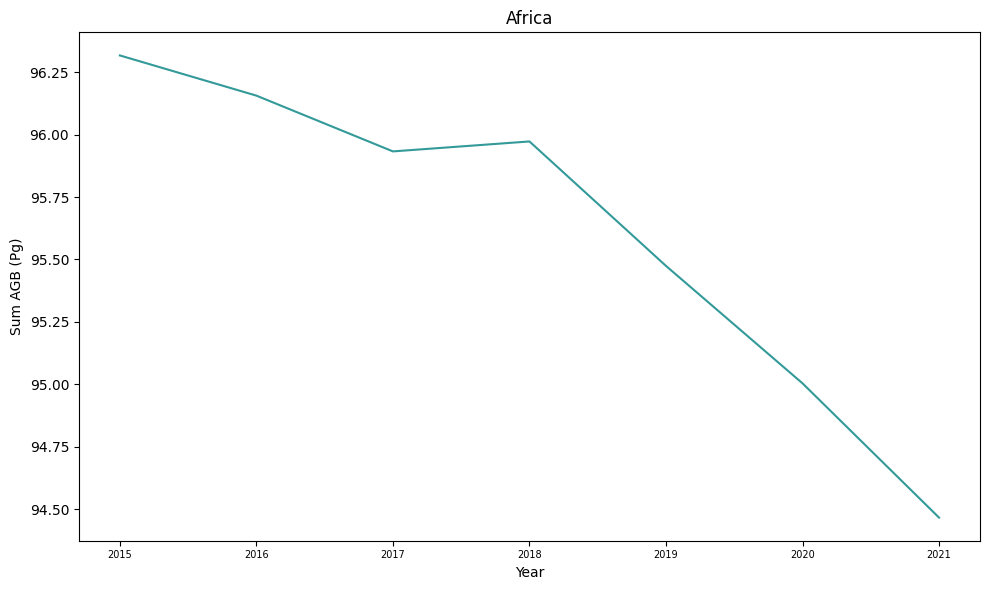

In [ ]:
fig1, ax1 = plt.subplots(figsize=(10, 6))#, dpi=300)

short = "Short vegetation 2015 <5m (GLCLU)"#
forests = "Trees 2015 >5m (GLCLU)"#"Forests 2005 (FCS)"#
land = "Land"

sns.lineplot(data=agb_t, x="Year", y=forests, color="teal", alpha=0.8)
#ax1.fill_between(agb_t["Year"], y1=agb_t[forests], y2=0,  color="grey", alpha=0.2, label=forests)

ax1.set_title(stratum)
ax1.tick_params(axis='x', labelsize=7)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
ax1.set_ylabel("Sum AGB (Pg)")
ax1.legend(loc='upper left', fontsize=10,frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()


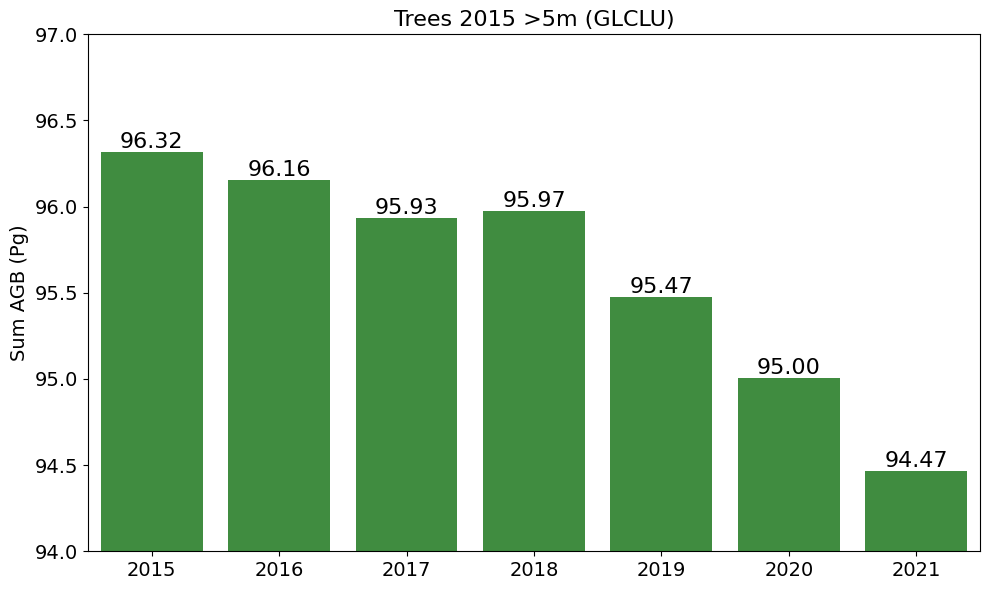

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.barplot(data=agb_t, x="Year", y=forests, color="green", alpha=0.8) #label=forests,
#sns.barplot(data=agb_t, x="Year", y=land, color="gold", label=land, alpha=0.8)
#sns.barplot(data=agb_t, x="Year", y=woody, color="olivedrab", label=woody, alpha=0.8)

ax2.set_title(forests, fontsize=16)
#ax2.set_title(stratum + ' - Sum AGB (Pg)')
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_xlabel("")
ax2.set_ylabel("Sum AGB (Pg)", fontsize=14)
ax2.set_ylim(94, 97)#125)
#ax2.legend(loc='upper left', fontsize=10, frameon=False)
plt.grid(False)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', label_type='edge', fontsize=16)

plt.tight_layout()
plt.show()

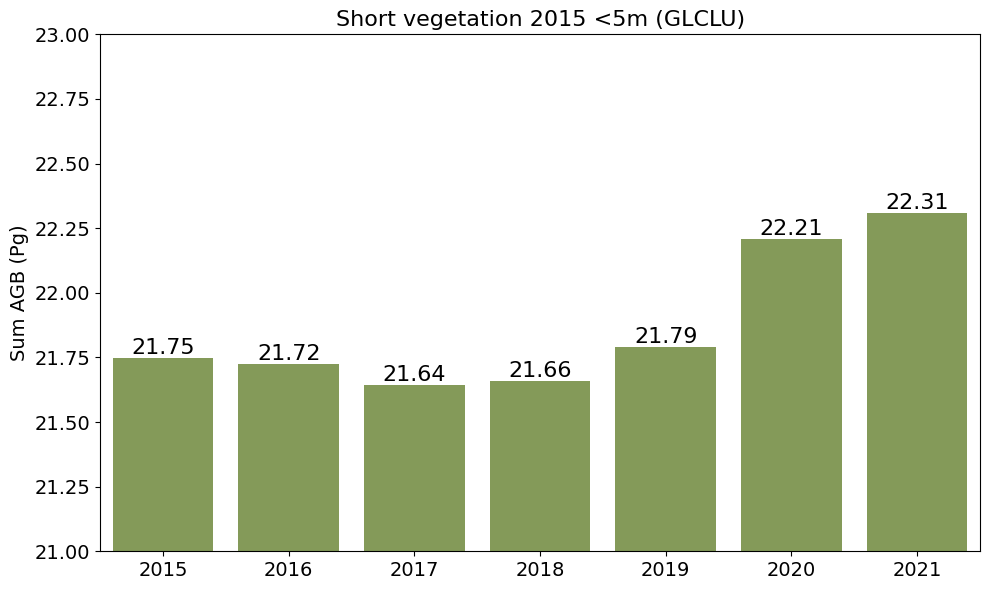

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 6))
#sns.barplot(data=agb_t, x="Year", y=forests, color="green", alpha=0.8) #label=forests,
#sns.barplot(data=agb_t, x="Year", y=land, color="gold", label=land, alpha=0.8)
sns.barplot(data=agb_t, x="Year", y=short, color="olivedrab", alpha=0.8)#label=woody,

ax2.set_title(short, fontsize=16)
#ax2.set_title(stratum + ' - Sum AGB (Pg)')
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_xlabel("")
ax2.set_ylabel("Sum AGB (Pg)", fontsize=14)
ax2.set_ylim(21, 23)#125)
#ax2.legend(loc='upper left', fontsize=10, frameon=False)
plt.grid(False)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', label_type='edge', fontsize=16)

plt.tight_layout()
plt.show()

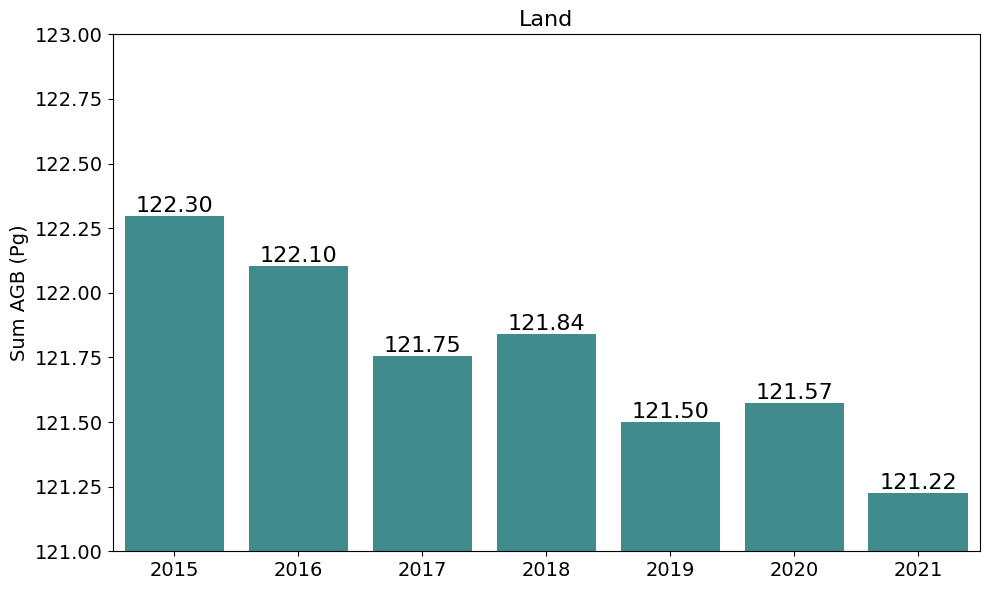

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 6))
#sns.barplot(data=agb_t, x="Year", y=forests, color="green", alpha=0.8) #label=forests,
sns.barplot(data=agb_t, x="Year", y=land, color="teal", alpha=0.8) # label=land,
#sns.barplot(data=agb_t, x="Year", y=short, color="olivedrab", alpha=0.8)#label=woody,

ax2.set_title(land, fontsize=16)
#ax2.set_title(stratum + ' - Sum AGB (Pg)')
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_xlabel("")
ax2.set_ylabel("Sum AGB (Pg)", fontsize=14)
ax2.set_ylim(121, 123)#125)
#ax2.legend(loc='upper left', fontsize=10, frameon=False)
plt.grid(False)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', label_type='edge', fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
stratum = 'Africa'
variable = 'MaskAreas'
stat_name = 'sums'
prefix = variable+ '_' + stat_name + '_' + stratum + '_'
suffix = '_' + res +'m'

filtered_file = [f for f in all_files if prefix in f]
csv_files = [f for f in filtered_file if f.lower().endswith('.csv')]
csv_file_paths = [os.path.join(folder_path, f) for f in csv_files]
csv_file_paths

['/content/drive/MyDrive/NCEO_AGB_Africa_Change/10000m/MaskAreas_sums_Africa_GLCLUforests_2015_10000m.csv',
 '/content/drive/MyDrive/NCEO_AGB_Africa_Change/10000m/MaskAreas_sums_Africa_landmask_10000m.csv',
 '/content/drive/MyDrive/NCEO_AGB_Africa_Change/10000m/MaskAreas_sums_Africa_GLCLUshortVeg_2015_10000m.csv']

In [ ]:
dfs = []
for f in csv_file_paths:
    stem = Path(f).stem  # remove .csv
    mask = stem.removeprefix(prefix).removesuffix(suffix)
    temp = pd.read_csv(f)
    temp["Mask"] = mask
    dfs.append(temp)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=["system:index", '.geo'])


mask_name_mapping = {
                      'landmask': 'Land',
                      'GLCLUforests_2015': "Trees 2015 >5m (GLCLU)",
                      'GLCLUshortVeg_2015':"Short vegetation 2015 <5m (GLCLU)",
                      # "FCSwoody2005": "Woody 2005 (FCS)",
                      # "FCSforest2005": "Forests 2005 (FCS)",
                      # "canopy_10pc_2005": "Canopy >10% 2005 (NASA)",
                      # 'lowFragmentation2020': 'Non-fragmented 2020',
                      # 'highFragmentation2020': 'Fragmented 2020',
                      # 'plantations2021':'Plantations 2021',
                      # 'plantations2015':'Plantations 2015',
                      # 'agroforestry2015': 'Agroforestry 2015',
                      # 'managed2015': 'Managed 2015',
                      # "ifl2025":"Intact forests 2025",
                      # 'nonifl2025':"Non-intact forests 2025",
                      # 'fire': 'Fire',
                      # 'nonFire': 'Non-fire',
                      # 'deforested': 'Deforested',
                      # 'regrowing': 'Regrowing'
}
df['Mask'] = df['Mask'].replace(mask_name_mapping)
df = df.T.reset_index()
df.columns = df.iloc[1]
df = df.drop([1])
df_maskAreas = df
df_maskAreas

1,Mask,Trees 2015 >5m (GLCLU),Land,Short vegetation 2015 <5m (GLCLU)
0,sum,70168.32549,357344.541176,122898.215686


In [ ]:
masks_forests = ['Land',"Trees 2015 >5m (GLCLU)","Short vegetation 2015 <5m (GLCLU)"#, "Woody 2005 (FCS)","Forests 2005 (FCS)",  "Canopy >10% 2005 (NASA)","Vegetation <5m (GLCLU)"
                 ]
#masks_humans = ['Non-fragmented 2020', 'Fragmented 2020', 'Plantations 2021','Plantations 2015','Agroforestry 2015','Managed 2015']
#masks_state = ["Intact forests 2025", "Non-intact forests 2025", 'Fire', 'Non-fire', 'Deforested', 'Regrowing']

masks = masks_forests

In [ ]:
variable = 'NetDif'
stratum = 'Africa'
stat_name = 'stats'
prefix = variable+ '_' + stat_name + '_' + stratum + '_'
suffix = '_'+res+'m'

filtered_file = [f for f in all_files if prefix in f]
csv_files = [f for f in filtered_file if f.lower().endswith('.csv')]
csv_file_paths = [os.path.join(folder_path, f) for f in csv_files]
csv_file_paths

dfs = []
for f in csv_file_paths:
    stem = Path(f).stem
    mask = stem.removeprefix(prefix).removesuffix(suffix)
    temp = pd.read_csv(f)
    temp["Mask"] = mask
    dfs.append(temp)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=["system:index", '.geo'])

mask_name_mapping = {
                      'landmask': 'Land',
                      'GLCLUforests_2015': "Trees 2015 >5m (GLCLU)",
                      'GLCLUshortVeg_2015':"Short vegetation 2015 <5m (GLCLU)",
                      # "FCSwoody2005": "Woody 2005 (FCS)",
                      # "FCSforest2005": "Forests 2005 (FCS)",
                      # "canopy_10pc_2005": "Canopy >10% 2005 (NASA)",
                      # 'lowFragmentation2020': 'Non-fragmented 2020',
                      # 'highFragmentation2020': 'Fragmented 2020',
                      # 'plantations2021':'Plantations 2021',
                      # 'plantations2015':'Plantations 2015',
                      # 'agroforestry2015': 'Agroforestry 2015',
                      # 'managed2015': 'Managed 2015',
                      # "ifl2025":"Intact forests 2025",
                      # 'nonifl2025':"Non-intact forests 2025",
                      # 'fire': 'Fire',
                      # 'nonFire': 'Non-fire',
                      # 'deforested': 'Deforested',
                      # 'regrowing': 'Regrowing'
}
df['Mask'] = df['Mask'].replace(mask_name_mapping)
df['Mask'] = pd.Categorical(df['Mask'], categories=masks, ordered=True)
df = df.sort_values('Mask')
df_nedDif = df
df_nedDif

,mean,p0,p100,p25,p50,p75,stdDev,sum,Mask
1,-0.574958,-186.0,130.0,-1.370309,0.421679,4.452820,12.681921,-107171.0,Land
0,-2.670322,-186.0,128.0,-9.475221,0.507443,6.475627,18.818799,-185072.0,Trees 2015 >5m (GLCLU)
2,0.593424,-171.0,130.0,-1.348839,0.405903,2.407061,6.380932,56024.0,Short vegetation 2015 <5m (GLCLU)


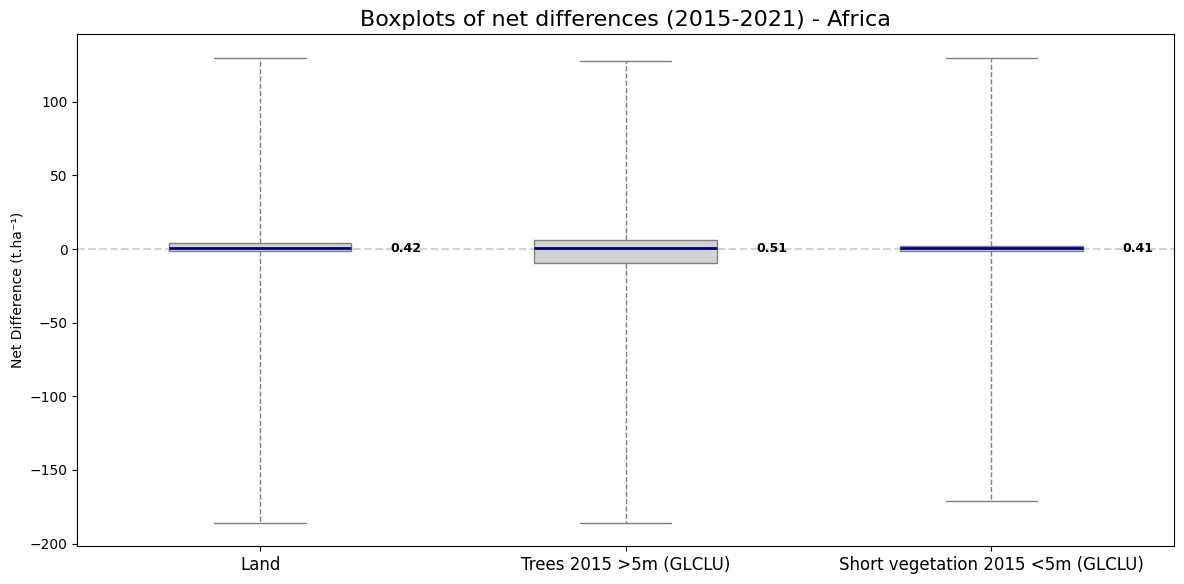

In [ ]:
df_nedDif_plot = df_nedDif[df_nedDif['Mask'].isin(masks)]

boxplot_stats = []
labels = []

for index, row in df_nedDif_plot.iterrows():
    stats = {
        'med': row['p50'],
        'q1': row['p25'],
        'q3': row['p75'],
        'whislo': row['p0'],
        'whishi': row['p100'],
        'fliers': []
    }
    boxplot_stats.append(stats)
    labels.append(row['Mask'])


fig, ax = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax.axhline(0, color='lightgray', linewidth=1.5, linestyle='--', zorder=1)

ax.bxp(boxplot_stats, showfliers=False, patch_artist=True,
       boxprops=dict(facecolor='lightgrey', edgecolor='grey'),
       medianprops=dict(color='darkblue', linewidth=2),
       whiskerprops=dict(color='gray', linestyle='--'),
       capprops=dict(color='gray'), widths=0.5)

for i, stats in enumerate(boxplot_stats, start=1):
    median = stats['med']
    ax.text(i+0.4, median,
            f"{median:.2f}",
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            color='black')

ax.set_xticklabels(labels, rotation=0, ha='center',fontsize=12)
ax.set_title('Boxplots of net differences (2015-2021) - '+stratum,fontsize=16)
ax.set_ylabel('Net Difference (t.ha\u207b\u00b9)')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(False)
plt.tight_layout()
plt.show()

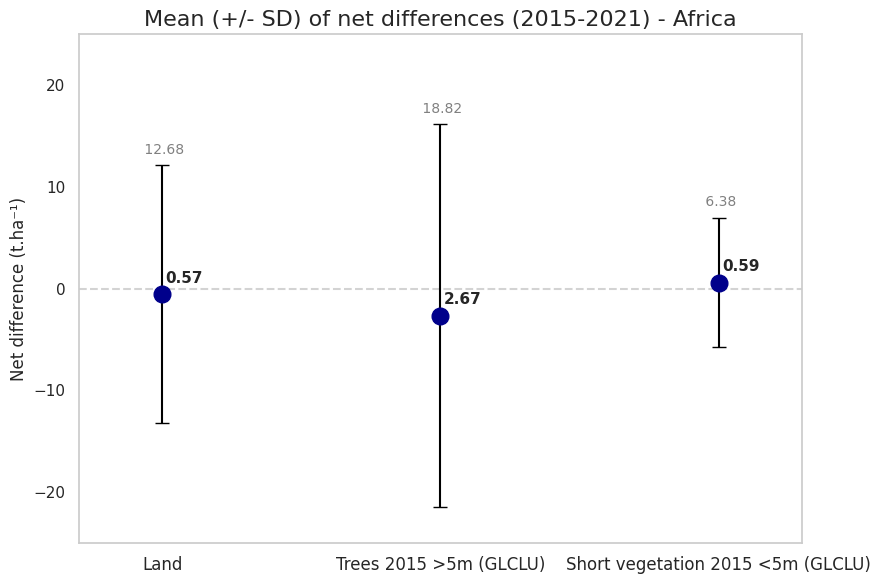

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 6))#, dpi=150)
ax.axhline(0, color='lightgray', linewidth=1.5, linestyle='--', zorder=1)
x_positions = np.arange(len(df_nedDif_plot))

means = df_nedDif_plot['mean'].values
stds = df_nedDif_plot['stdDev'].values


ax.errorbar(
    x_positions,
    means,
    yerr=stds,
    fmt='o',# circle marker
    markersize=12,# large dot
    color='darkblue',
    ecolor='black',
    capsize=5,
    elinewidth=1.5
)


for i, mean_val in enumerate(means):
    ax.text(
        x_positions[i] +0.08,
        mean_val + 0.02*(ax.get_ylim()[1] - ax.get_ylim()[0]),
        f"{abs(mean_val):.2f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

    ax.text(
        x_positions[i],
        means[i] + stds[i] + 0.02*(ax.get_ylim()[1] - ax.get_ylim()[0]), # Above the error bar cap
        f" {abs(stds[i]):.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='gray'
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(df_nedDif_plot['Mask'], rotation=0, ha='center', fontsize=12)
ax.set_title('Mean (+/- SD) of net differences (2015-2021) - '+stratum,fontsize=16)
ax.set_ylim(-25, 25)
ax.set_xlim(-0.3, 2.3)
ax.set_xlabel('')
ax.set_ylabel('Net difference (t.ha\u207b\u00b9)')
plt.grid(False)
plt.tight_layout()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
plt.show()

In [ ]:
variable = 'AnnualAGBChange'
stratum = 'Africa'
stat_name = 'stats'
prefix = variable+ '_' + stat_name + '_' + stratum + '_'
suffix = '_changeThreshold_0_01_'+res+'m'

filtered_file = [f for f in all_files if prefix in f]
csv_files = [f for f in filtered_file if f.lower().endswith('.csv')]
csv_file_paths = [os.path.join(folder_path, f) for f in csv_files]
csv_file_paths

dfs = []
for f in csv_file_paths:
    stem = Path(f).stem  # remove .csv
    mask = stem.removeprefix(prefix).removesuffix(suffix)
    temp = pd.read_csv(f)
    temp["Mask"] = mask
    dfs.append(temp)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=["system:index", '.geo'])

mask_name_mapping = {
                      'landmask': 'Land',
                      'GLCLUforests_2015': "Trees 2015 >5m (GLCLU)",
                      'GLCLUshortVeg_2015':"Short vegetation 2015 <5m (GLCLU)",
                      # "FCSwoody2005": "Woody 2005 (FCS)",
                      # "FCSforest2005": "Forests 2005 (FCS)",
                      # "canopy_10pc_2005": "Canopy >10% 2005 (NASA)",
                      # 'lowFragmentation2020': 'Non-fragmented 2020',
                      # 'highFragmentation2020': 'Fragmented 2020',
                      # 'plantations2021':'Plantations 2021',
                      # 'plantations2015':'Plantations 2015',
                      # 'agroforestry2015': 'Agroforestry 2015',
                      # 'managed2015': 'Managed 2015',
                      # "ifl2025":"Intact forests 2025",
                      # 'nonifl2025':"Non-intact forests 2025",
                      # 'fire': 'Fire',
                      # 'nonFire': 'Non-fire',
                      # 'deforested': 'Deforested',
                      # 'regrowing': 'Regrowing'
}
df['Mask'] = df['Mask'].replace(mask_name_mapping)
df = df.T.reset_index()
df.columns = df.iloc[-1]
df = df[:-1]
df['Variable'] = df['Mask'].apply(lambda x: x.split('_')[0])
df['Stat'] = df['Mask'].apply(lambda x: x.split('_')[-1])

var_name_mapping = {
    'senSlope': 'Sen slope',
    'rate': 'Rate'
}
df['Variable'] = df['Variable'].replace(var_name_mapping)
df = df.drop(columns = ['Mask'])
df_stats = df
df_stats

16,Trees 2015 >5m (GLCLU),Land,Short vegetation 2015 <5m (GLCLU),Variable,Stat
0,-0.445395,-0.096678,0.09541,Rate,mean
1,-26.333333,-26.333333,-26.0,Rate,p0
2,21.833333,21.833333,21.666667,Rate,p100
3,-1.412024,-0.401938,-0.166667,Rate,p25
4,0.084027,0.070481,0.068029,Rate,p50
5,1.079281,0.573557,0.571013,Rate,p75
6,3.135637,2.113062,1.065865,Rate,stdDev
7,-30835.166667,-18026.5,9031.166667,Rate,sum
8,-0.385949,-0.071521,0.108304,Sen slope,mean
9,-33.579948,-33.579948,-24.305298,Sen slope,p0


In [ ]:
df_means_filtered = df_stats[df_stats['Stat'] == 'mean'].copy()
df_std_filtered = df_stats[df_stats['Stat'] == 'stdDev'].copy()

ann_change_var = [#'Rate',
                  'Sen slope']

df_means_filtered = df_means_filtered[df_means_filtered['Variable'].isin(ann_change_var)]
df_std_filtered = df_std_filtered[df_std_filtered['Variable'].isin(ann_change_var)]

mask_value_columns = [col for col in df_means_filtered.columns
                             if col not in ['Mask', 'Variable', 'Stat']]

melted_means = df_means_filtered.melt(id_vars=['Variable'], value_vars=mask_value_columns, var_name='Mask', value_name='MeanValue')
melted_stds = df_std_filtered.melt(id_vars=['Variable'], value_vars=mask_value_columns, var_name='Mask', value_name='StdDevValue')

df_plot_stats = pd.merge(melted_means, melted_stds, on=['Variable', 'Mask'], how='inner')


df_plot_stats['MeanValue'] = pd.to_numeric(df_plot_stats['MeanValue'])
df_plot_stats['StdDevValue'] = pd.to_numeric(df_plot_stats['StdDevValue'])

df_plot_stats

,Variable,Mask,MeanValue,StdDevValue
0,Sen slope,Trees 2015 >5m (GLCLU),-0.385949,2.817500
1,Sen slope,Land,-0.071521,1.904331
2,Sen slope,Short vegetation 2015 <5m (GLCLU),0.108304,0.972836


ValueError: cannot reindex on an axis with duplicate labels

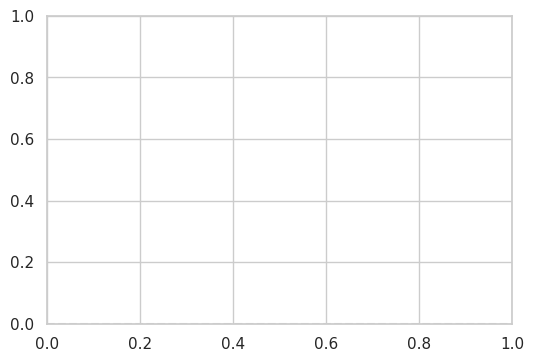

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))#, dpi=300)
ax.axhline(0, color='lightgray', linewidth=1.5, linestyle='--', zorder=1)
variable_order = [#'Rate',
                  'Sen slope']
#
x = np.arange(len(masks))

colors = [#'#1f78b4',
          '#005500']#['#F2EFE9', '#D1C7BD', '#2F4858', '#1B263B']#sns.color_palette('viridis', n_colors=len(variable_order)),


for i, var in enumerate(variable_order):
    subset = df_plot_stats[df_plot_stats['Variable'] == var]
    subset = subset.set_index('Mask').reindex(masks).reset_index()

    bar_width = 0.2
    num_variables = len(variable_order)
    offset = (i - (num_variables - 1) / 2) * bar_width + 0.01

    ax.errorbar(
        x + offset,
        subset['MeanValue'],
        yerr=subset['StdDevValue'],
        fmt='o',
        capsize=5,
        color=colors[i],
        label=var,
        markersize=8,
        elinewidth=1.5
    )

    for j, (_, row) in enumerate(subset.iterrows()):
        ax.text(
            x[j] + offset ,
            row['MeanValue'] + 0.02, # Slightly above the mean point
            f'{row["MeanValue"]: .2f}',
            ha='left',
            va='bottom',
            fontsize=16,
            color=colors[i],
            fontweight='bold'
        )

        ax.text(
            x[j] + offset,
            row['MeanValue'] + row['StdDevValue'] + 0.05,
            f'{row["StdDevValue"]: .2f}',
            ha='center',
            va='bottom',
            fontsize=12,
            color='gray'
        )

ax.set_xticks(x)
ax.set_ylim(-3.5, 3.5)
# Fix: Apply textwrap.fill to each element in masks
ax.set_xticklabels([textwrap.fill(m, width=20) for m in masks] , rotation=0, ha='center', fontsize=12)
#ax.set_title('Mean (+/- SD) of annual change metrics (2015-2021) - '+stratum, fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('Sen slope (t.ha⁻¹.yr⁻¹)', fontsize=12)
#ax.legend(title='', loc='upper left',frameon=False) #bbox_to_anchor=(1.05, 1),

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.grid(False)
plt.show()

In [ ]:
# stratum = 'Africa'
# variable = 'AnnualAGBChangeAreas'
# stat_name = 'sums'
# prefix = variable+ '_' + stat_name + '_' + stratum + '_'
# suffix = '_changeThreshold_0_01_'+res+'m'

# filtered_file = [f for f in all_files if prefix in f]
# csv_files = [f for f in filtered_file if f.lower().endswith('.csv')]
# csv_file_paths = [os.path.join(folder_path, f) for f in csv_files]
# csv_file_paths

# dfs = []
# for f in csv_file_paths:
#     stem = Path(f).stem  # remove .csv
#     mask = stem.removeprefix(prefix).removesuffix(suffix)
#     temp = pd.read_csv(f)
#     temp["Mask"] = mask
#     dfs.append(temp)
# df = pd.concat(dfs, ignore_index=True)
# df = df.drop(columns=["system:index", '.geo'])


# mask_name_mapping = {
#                       'landmask': 'Land',
#                       'GLCLUforests_2015': "Trees 2015 >5m (GLCLU)",
#                       'GLCLUshortVeg_2015':"Short vegetation 2015 <5m (GLCLU)",
#                       # "FCSwoody2005": "Woody 2005 (FCS)",
#                       # "FCSforest2005": "Forests 2005 (FCS)",
#                       # "canopy_10pc_2005": "Canopy >10% 2005 (NASA)",
#                       # 'lowFragmentation2020': 'Non-fragmented 2020',
#                       # 'highFragmentation2020': 'Fragmented 2020',
#                       # 'plantations2021':'Plantations 2021',
#                       # 'plantations2015':'Plantations 2015',
#                       # 'agroforestry2015': 'Agroforestry 2015',
#                       # 'managed2015': 'Managed 2015',
#                       # "ifl2025":"Intact forests 2025",
#                       # 'nonifl2025':"Non-intact forests 2025",
#                       # 'fire': 'Fire',
#                       # 'nonFire': 'Non-fire',
#                       # 'deforested': 'Deforested',
#                       # 'regrowing': 'Regrowing'
# }
# df['Mask'] = df['Mask'].replace(mask_name_mapping)
# df = df.T.reset_index()
# df.columns = df.iloc[-1]
# df = df[:-1]
# df_areas = df
# df_areas

In [ ]:
# df_areas['Variable'] = df_areas['Mask']
# df_areas['Variable'] = df_areas['Variable'].apply(lambda x: x.split('_')[0])
# var_name_mapping = {
#     'senSlope': 'Sen slope',
#     'rate': 'Rate',
#     'shifts': 'Shifting',
#     'unidirectionalSenSlope': 'Unidirectional',
#     'decGain': 'Decelerating (or reversing)',
#     'decLoss': 'Decelerating (or reversing)',
#     'accGain': 'Accelerating',
#     'accLoss': 'Accelerating'
# }
# df_areas['Variable'] = df_areas['Variable'].replace(var_name_mapping)


# def get_direction(mask_name):
#     if 'gain_Area_Mha' in mask_name:
#         return 'Gain'
#     elif 'loss_Area_Mha' in mask_name:
#         return 'Loss'
#     elif 'Loss_Area_Mha' in mask_name:
#         return 'Loss'
#     elif 'Gain_Area_Mha' in mask_name:
#         return 'Gain'
#     return np.nan
# df_areas['Direction'] = df_areas['Mask']
# df_areas['Direction'] = df_areas['Direction'].apply(get_direction)
# df_areas

In [ ]:
annChangeVar = [#'Rate',
                'Sen slope']
df_areas_annChangeVar = df_areas[df_areas['Variable'].isin(annChangeVar)].copy()

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        absolute = pct/100.*total
        return f'{pct:.2f}%\n({absolute:,.2f} Mha)'
    return my_autopct


fig, axes = plt.subplots(len(annChangeVar), len(masks), figsize=(20, 8))

colors = [#'#C5E0B4',
          '#D6BBEB']


for var_idx, var in enumerate(annChangeVar):

    for mask_idx, mask_col in enumerate(masks):
        ax = axes[var_idx, mask_idx]

        gain_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Gain')]
        loss_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Loss')]

        gain_value = gain_row[mask_col].values[0] if not gain_row.empty else 0
        loss_value = loss_row[mask_col].values[0] if not loss_row.empty else 0

        data = [gain_value, loss_value]

        if sum(data) > 0:
            ax.pie(data, autopct=make_autopct(data), startangle=90, colors=colors, textprops={'fontsize': 12})
            ax.axis('equal')
        else:
            ax.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')


        if var_idx == 0:
            ax.set_title(mask_col, fontsize=14, fontweight='bold')


    y_pos = (1 - (var_idx + 0.5) / len(annChangeVar))
    fig.text(0.03, y_pos, var, ha='center', va='center', rotation='vertical', fontsize=18, fontweight='bold')
legend_elements = [Patch(facecolor=colors[0], label='Gain (>0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)'),
                   Patch(facecolor=colors[1], label='Loss (<-0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)')]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           fancybox=True, shadow=False, ncol=2, fontsize=16,frameon=False)

plt.tight_layout(rect=[0.05, 0, 1, 0.95]) # [left, bottom, right, top]
plt.show()

NameError: name 'df_areas' is not defined

In [ ]:
annChangeVar = ['Unidirectional','Shifting']
df_areas_annChangeVar = df_areas[df_areas['Variable'].isin(annChangeVar)].copy()

fig, axes = plt.subplots(1, len(masks), figsize=(5 * len(masks),5))

colors = ['#C5E0B4', '#D6BBEB']

for mask_idx, mask_col in enumerate(masks):

    if len(masks) == 1:
        ax = axes
    else:
        ax = axes[mask_idx]

    gain_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == 'Unidirectional')]
    loss_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == 'Shifting')]

    gain_value = gain_row[mask_col].values[0] if not gain_row.empty else 0
    loss_value = loss_row[mask_col].values[0] if not loss_row.empty else 0

    data = [gain_value, loss_value]

    ax.pie(data, autopct=make_autopct(data), startangle=90, colors=colors, textprops={'fontsize': 12})
    ax.axis('equal')
    ax.set_title(mask_col, fontsize=14, fontweight='bold')

legend_elements = [Patch(facecolor=colors[0], label='Unidirectional', ),
                   Patch(facecolor=colors[1], label='Shifting')]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), fancybox=True, shadow=False, ncol=2, fontsize=16,frameon=False)

fig.suptitle('Shifting vs unidirectional changes', fontsize=20, y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.2]) # [left, bottom, right, top]
plt.show()

In [ ]:
annChangeVar = ['Accelerating','Decelerating (or reversing)'] #
df_areas_annChangeVar = df_areas[df_areas['Variable'].isin(annChangeVar)].copy()


fig, axes = plt.subplots(len(annChangeVar), len(masks), figsize=(20, 8))

colors = ['#C5E0B4', '#D6BBEB']


for var_idx, var in enumerate(annChangeVar):

    for mask_idx, mask_col in enumerate(masks):
        ax = axes[var_idx, mask_idx]

        gain_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Gain')]
        loss_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Loss')]

        gain_value = gain_row[mask_col].values[0] if not gain_row.empty else 0
        loss_value = loss_row[mask_col].values[0] if not loss_row.empty else 0

        data = [gain_value, loss_value]

        if sum(data) > 0:
            ax.pie(data, autopct=make_autopct(data), startangle=90, colors=colors, textprops={'fontsize': 12})
            ax.axis('equal')
        else:
            ax.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')


        if var_idx == 0:
            ax.set_title(mask_col, fontsize=14, fontweight='bold')


    y_pos = (1 - (var_idx + 0.5) / len(annChangeVar))
    fig.text(0.03, y_pos, var, ha='center', va='center', rotation='vertical', fontsize=18, fontweight='bold')
legend_elements = [Patch(facecolor=colors[0], label='Gain (>0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)'),
                   Patch(facecolor=colors[1], label='Loss (<-0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)')]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           fancybox=True, shadow=False, ncol=2, fontsize=16,frameon=False)

plt.tight_layout(rect=[0.05, 0, 1, 0.95]) # [left, bottom, right, top]
plt.show()

# 6- Stats Biome

In [ ]:
variable = 'NetDif'
stratum = 'forestEcobiomes'
stat_name = 'stats'
prefix = variable+ '_' + stat_name + '_' + stratum + '_'
suffix = '_'+res+'m'

folder_path_strat = folder_path + stratum
all_files_strat = [f for f in os.listdir(folder_path_strat) if os.path.isfile(os.path.join(folder_path_strat, f))]
filtered_file = [f for f in all_files_strat if prefix in f]
csv_files = [f for f in filtered_file if f.lower().endswith('.csv')]
csv_file_paths = [os.path.join(folder_path_strat, f) for f in csv_files]
csv_file_paths

dfs = []
for f in csv_file_paths:
    stem = Path(f).stem
    mask = stem.removeprefix(prefix).removesuffix(suffix)
    temp = pd.read_csv(f)
    temp["Mask"] = mask
    dfs.append(temp)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=["system:index", '.geo'])

mask_name_mapping = {
                      #'landmask': 'Land',
                      'GLCLUforests_2015': "Trees 2015 >5m (GLCLU)",
                      #'GLCLUshortVeg_2015':"Short vegetation 2015 <5m (GLCLU)",
                      # "FCSwoody2005": "Woody 2005 (FCS)",
                      # "FCSforest2005": "Forests 2005 (FCS)",
                      # "canopy_10pc_2005": "Canopy >10% 2005 (NASA)",
                      # 'lowFragmentation2020': 'Non-fragmented 2020',
                      # 'highFragmentation2020': 'Fragmented 2020',
                      # 'plantations2021':'Plantations 2021',
                      # 'plantations2015':'Plantations 2015',
                      # 'agroforestry2015': 'Agroforestry 2015',
                      # 'managed2015': 'Managed 2015',
                      # "ifl2025":"Intact forests 2025",
                      # 'nonifl2025':"Non-intact forests 2025",
                      # 'fire': 'Fire',
                      # 'nonFire': 'Non-fire',
                      # 'deforested': 'Deforested',
                      # 'regrowing': 'Regrowing'
}
df['Mask'] = df['Mask'].replace(mask_name_mapping)

df_nedDif = df
df_nedDif

,ECO_BIOME_,mean,p0,p100,p25,p50,p75,stdDev,sum,Mask
0,AF01,-8.389195,-186.0,128.0,-21.384202,-5.4975,6.481932,25.838901,-208878.121569,Trees 2015 >5m (GLCLU)
1,AF02,-4.292212,-83.0,38.0,-9.000000,-2.0000,1.000000,10.141351,-2450.415686,Trees 2015 >5m (GLCLU)
2,AF12,0.509183,-96.0,24.0,-1.000000,2.0000,4.000000,12.736524,69.796078,Trees 2015 >5m (GLCLU)
3,AF14,-9.516201,-85.0,53.0,-20.000000,-4.0000,1.000000,18.271751,-2138.756863,Trees 2015 >5m (GLCLU)
4,IN14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Trees 2015 >5m (GLCLU)
5,PA04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Trees 2015 >5m (GLCLU)
6,PA05,2.556227,-44.0,20.0,-1.000000,6.0000,11.000000,12.011464,192.458824,Trees 2015 >5m (GLCLU)
7,PA12,5.243872,-44.0,47.0,2.000000,6.0000,10.000000,8.480214,1611.678431,Trees 2015 >5m (GLCLU)


In [ ]:
biome_dic = {
    '01': 'Tropical moist broadleaf',
    '02': 'Tropical dry broadleaf',
    '03': 'Tropical conifer',
    '04': 'Temperate broadleaf & mixed',
    '05': 'Temperate conifer',
    '06': 'Boreal',
    '07': 'Tropical grasslands, savannas & shrublands',
    '12': 'Mediterranean',
    '14': 'Mangroves'
}

realm_dic = {
    'AF': 'Afrotropic',
    'AU': 'Australasia',
    'IN': 'Indomalay',
    'NE': 'Nearctic',
    'NO': 'Neotropic',
    'OC': 'Oceania',
    'PA': 'Palearctic'
}

color_map = {
    '01': '#359700',
    '02': '#458970',
    '03': '#92A837',
    '04': '#CCC202',
    '05': '#993300',
    '06': '#CC99FF',
    '07': '#666666',
    '12': '#FF99CC',
    '14': '#00CCFF'
}

In [ ]:
biomes = gpd.read_file('/content/drive/MyDrive/Ecoregions2017/Ecoregions2017.shp')
biomes['color'] = biomes['BIOME_NUM'].astype(int).astype(str).str.zfill(2).map(color_map)

In [ ]:
df_nedDif

,ECO_BIOME_,mean,p0,p100,p25,p50,p75,stdDev,sum,Mask
0,AF01,-8.389195,-186.0,128.0,-21.384202,-5.4975,6.481932,25.838901,-208878.121569,Trees 2015 >5m (GLCLU)
1,AF02,-4.292212,-83.0,38.0,-9.000000,-2.0000,1.000000,10.141351,-2450.415686,Trees 2015 >5m (GLCLU)
2,AF12,0.509183,-96.0,24.0,-1.000000,2.0000,4.000000,12.736524,69.796078,Trees 2015 >5m (GLCLU)
3,AF14,-9.516201,-85.0,53.0,-20.000000,-4.0000,1.000000,18.271751,-2138.756863,Trees 2015 >5m (GLCLU)
4,IN14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Trees 2015 >5m (GLCLU)
5,PA04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Trees 2015 >5m (GLCLU)
6,PA05,2.556227,-44.0,20.0,-1.000000,6.0000,11.000000,12.011464,192.458824,Trees 2015 >5m (GLCLU)
7,PA12,5.243872,-44.0,47.0,2.000000,6.0000,10.000000,8.480214,1611.678431,Trees 2015 >5m (GLCLU)


In [ ]:
df_nedDif['Biome'] = df_nedDif['ECO_BIOME_'].str[-2:]
df_nedDif['Realm'] = df_nedDif['ECO_BIOME_'].str[:2]
df_nedDif['Biome_name'] = df_nedDif['ECO_BIOME_'].str[-2:].map(biome_dic)
df_nedDif['Realm_name'] = df_nedDif['ECO_BIOME_'].str[:2].map(realm_dic)
df_nedDif['Ecobiome_name'] = df_nedDif['Realm_name']  + ' ' + df_nedDif['Biome_name']
df_nedDif['Colour'] = df_nedDif['Biome'].astype(int).astype(str).str.zfill(2).map(color_map)
df_nedDif


,ECO_BIOME_,mean,p0,p100,p25,p50,p75,stdDev,sum,Mask,Biome,Realm,Biome_name,Realm_name,Ecobiome_name,Colour
0,AF01,-8.389195,-186.0,128.0,-21.384202,-5.4975,6.481932,25.838901,-208878.121569,Trees 2015 >5m (GLCLU),01,AF,Tropical moist broadleaf,Afrotropic,Afrotropic Tropical moist broadleaf,#359700
1,AF02,-4.292212,-83.0,38.0,-9.000000,-2.0000,1.000000,10.141351,-2450.415686,Trees 2015 >5m (GLCLU),02,AF,Tropical dry broadleaf,Afrotropic,Afrotropic Tropical dry broadleaf,#458970
2,AF12,0.509183,-96.0,24.0,-1.000000,2.0000,4.000000,12.736524,69.796078,Trees 2015 >5m (GLCLU),12,AF,Mediterranean,Afrotropic,Afrotropic Mediterranean,#FF99CC
3,AF14,-9.516201,-85.0,53.0,-20.000000,-4.0000,1.000000,18.271751,-2138.756863,Trees 2015 >5m (GLCLU),14,AF,Mangroves,Afrotropic,Afrotropic Mangroves,#00CCFF
4,IN14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Trees 2015 >5m (GLCLU),14,IN,Mangroves,Indomalay,Indomalay Mangroves,#00CCFF
5,PA04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Trees 2015 >5m (GLCLU),04,PA,Temperate broadleaf & mixed,Palearctic,Palearctic Temperate broadleaf & mixed,#CCC202
6,PA05,2.556227,-44.0,20.0,-1.000000,6.0000,11.000000,12.011464,192.458824,Trees 2015 >5m (GLCLU),05,PA,Temperate conifer,Palearctic,Palearctic Temperate conifer,#993300
7,PA12,5.243872,-44.0,47.0,2.000000,6.0000,10.000000,8.480214,1611.678431,Trees 2015 >5m (GLCLU),12,PA,Mediterranean,Palearctic,Palearctic Mediterranean,#FF99CC


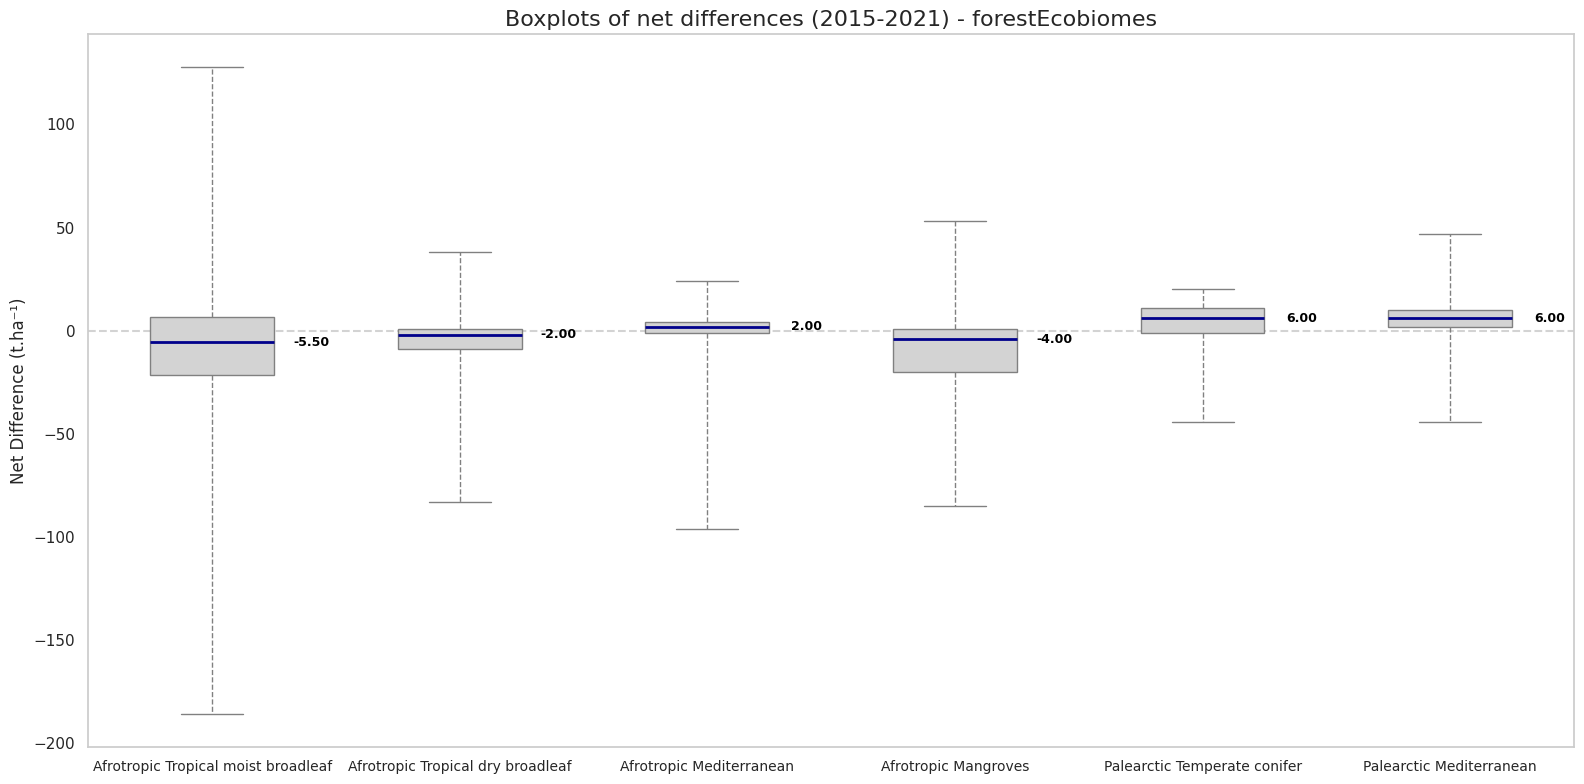

In [ ]:
ecobiomes = ['AF01', 'AF02', 'AF07', 'AF12', 'AF14', 'PA05', 'PA12']
df_nedDif_plot = df_nedDif[df_nedDif['ECO_BIOME_'].isin(ecobiomes)]

boxplot_stats = []
labels = []

for index, row in df_nedDif_plot.iterrows():
    stats = {
        'med': row['p50'],
        'q1': row['p25'],
        'q3': row['p75'],
        'whislo': row['p0'],
        'whishi': row['p100'],
        'fliers': []
    }
    boxplot_stats.append(stats)
    labels.append(row['Ecobiome_name'])


fig, ax = plt.subplots(figsize=(16,8))
ax.axhline(0, color='lightgray', linewidth=1.5, linestyle='--', zorder=1)
sns.set_theme(style="whitegrid")

ax.bxp(boxplot_stats, showfliers=False, patch_artist=True,
       boxprops=dict(facecolor='lightgrey', edgecolor='grey'),
       medianprops=dict(color='darkblue', linewidth=2),
       whiskerprops=dict(color='gray', linestyle='--'),
       capprops=dict(color='gray'), widths=0.5)

for i, stats in enumerate(boxplot_stats, start=1):
    median = stats['med']
    ax.text(i+0.4, median,
            f"{median:.2f}",
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            color='black')

ax.set_xticklabels(labels, rotation=0, ha='center',fontsize=10)
ax.set_title('Boxplots of net differences (2015-2021) - '+stratum,fontsize=16)
ax.set_ylabel('Net Difference (t.ha\u207b\u00b9)')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(False)
plt.tight_layout()
plt.show()

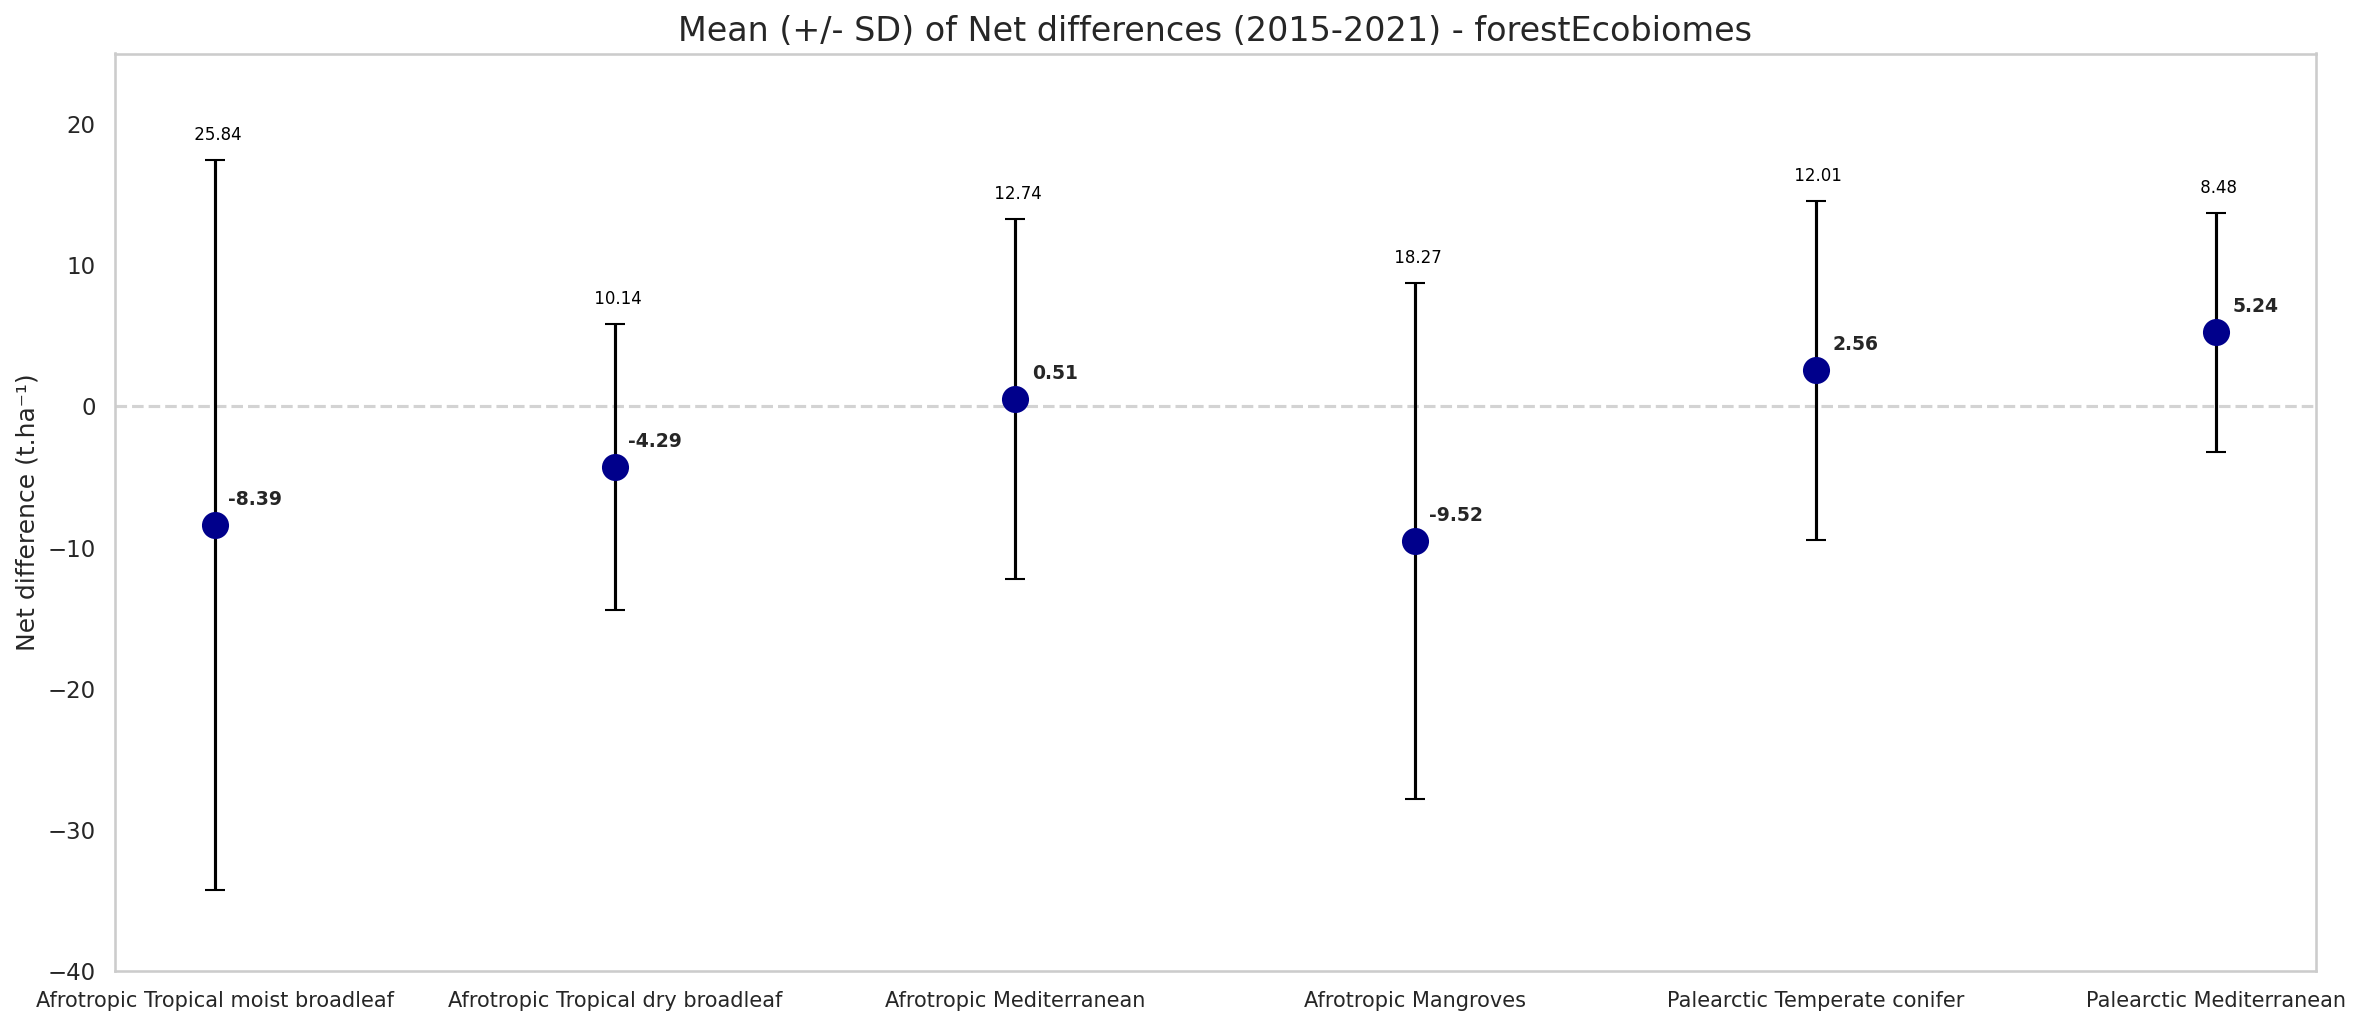

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(16, 7), dpi=150)
ax.axhline(0, color='lightgray', linewidth=1.5, linestyle='--', zorder=1)
x_positions = np.arange(len(df_nedDif_plot))

means = df_nedDif_plot['mean'].values
stds = df_nedDif_plot['stdDev'].values


ax.errorbar(
    x_positions,
    means,
    yerr=stds,
    fmt='o',# circle marker
    markersize=12,# large dot
    color='darkblue',
    ecolor='black',
    capsize=5,
    elinewidth=1.5
)


for i, mean_val in enumerate(means):
    ax.text(
        x_positions[i] +0.1,
        mean_val + 0.02*(ax.get_ylim()[1] - ax.get_ylim()[0]),
        f"{mean_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

    ax.text(
        x_positions[i],
        means[i] + stds[i] + 0.02*(ax.get_ylim()[1] - ax.get_ylim()[0]), # Above the error bar cap
        f" {stds[i]:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(df_nedDif_plot['Ecobiome_name'], rotation=0, ha='center', fontsize=10)
ax.set_title('Mean (+/- SD) of Net differences (2015-2021) - '+stratum, fontsize=16)
ax.set_xlabel('')
ax.set_ylim(-40, 25)
#ax.set_xlim(-0.3, 2.3)
ax.set_ylabel('Net difference (t.ha\u207b\u00b9)')
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
variable = 'AnnualAGBChange'
stratum = 'forestEcobiomes'
stat_name = 'stats'
prefix = variable+ '_' + stat_name + '_' + stratum + '_'
suffix = '_changeThreshold_0_01_'+res+'m'

folder_path_strat = folder_path + stratum
all_files_strat = [f for f in os.listdir(folder_path_strat) if os.path.isfile(os.path.join(folder_path_strat, f))]
filtered_file = [f for f in all_files_strat if prefix in f]
csv_files = [f for f in filtered_file if f.lower().endswith('.csv')]
csv_file_paths = [os.path.join(folder_path_strat, f) for f in csv_files]
csv_file_paths

dfs = []
for f in csv_file_paths:
    stem = Path(f).stem  # remove .csv
    mask = stem.removeprefix(prefix).removesuffix(suffix)
    temp = pd.read_csv(f)
    temp["Mask"] = mask
    dfs.append(temp)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=["system:index", '.geo'])

mask_name_mapping = {
                      'GLCLUforests_2015': "Trees 2015 >5m (GLCLU)",
}
df['Mask'] = df['Mask'].replace(mask_name_mapping)

# New logic for reshaping df_stats
# Identify value columns that start with 'rate_' or 'senSlope_'
value_vars = [col for col in df.columns if col.startswith(('rate_', 'senSlope_'))]

# Melt the DataFrame to long format
df_melted = df.melt(id_vars=['ECO_BIOME_', 'Mask'], value_vars=value_vars,
                     var_name='Metric', value_name='Value')

# Extract 'Variable' (e.g., 'Rate', 'Sen slope') and 'Stat' (e.g., 'mean', 'p0') from 'Metric'
df_melted['Variable'] = df_melted['Metric'].apply(lambda x: x.split('_')[0])
df_melted['Stat'] = df_melted['Metric'].apply(lambda x: '_'.join(x.split('_')[1:])) # Handle multi-word stats

# Map variable names for readability
var_name_mapping = {
    'senSlope': 'Sen slope',
    'rate': 'Rate'
}
df_melted['Variable'] = df_melted['Variable'].replace(var_name_mapping)

# Drop the original 'Metric' column
df_melted = df_melted.drop(columns=['Metric'])

df_stats = df_melted

In [ ]:
df_stats

,ECO_BIOME_,Mask,Value,Variable,Stat
0,AF01,Trees 2015 >5m (GLCLU),-1.403932,Rate,mean
1,AF02,Trees 2015 >5m (GLCLU),-0.718504,Rate,mean
2,AF12,Trees 2015 >5m (GLCLU),-0.043475,Rate,mean
3,AF14,Trees 2015 >5m (GLCLU),-1.790803,Rate,mean
4,IN14,Trees 2015 >5m (GLCLU),NaN,Rate,mean
...,...,...,...,...,...
123,AF14,Trees 2015 >5m (GLCLU),-312.614845,Sen slope,sum
124,IN14,Trees 2015 >5m (GLCLU),0.000000,Sen slope,sum
125,PA04,Trees 2015 >5m (GLCLU),0.000000,Sen slope,sum
126,PA05,Trees 2015 >5m (GLCLU),37.383339,Sen slope,sum


In [ ]:
df_means_filtered = df_stats[df_stats['Stat'] == 'mean'].copy()
df_std_filtered = df_stats[df_stats['Stat'] == 'stdDev'].copy()

ann_change_var = ['Rate',   'Sen slope']

df_means_filtered = df_means_filtered[df_means_filtered['Variable'].isin(ann_change_var)]
df_std_filtered = df_std_filtered[df_std_filtered['Variable'].isin(ann_change_var)]

# Rename 'Value' column to 'MeanValue' and 'StdDevValue' for merging
df_means_filtered = df_means_filtered.rename(columns={'Value': 'MeanValue'})
df_std_filtered = df_std_filtered.rename(columns={'Value': 'StdDevValue'})

# Merge on common identifier columns
df_plot_stats = pd.merge(df_means_filtered, df_std_filtered,
                         on=['ECO_BIOME_', 'Mask', 'Variable'],
                         how='inner')

df_plot_stats['Biome'] = df_plot_stats['ECO_BIOME_'].str[-2:]
df_plot_stats['Realm'] = df_plot_stats['ECO_BIOME_'].str[:2]
df_plot_stats['Biome_name'] = df_plot_stats['ECO_BIOME_'].str[-2:].map(biome_dic)
df_plot_stats['Realm_name'] = df_plot_stats['ECO_BIOME_'].str[:2].map(realm_dic)
df_plot_stats['Ecobiome_name'] = df_plot_stats['Realm_name']  + ' ' + df_plot_stats['Biome_name']
df_plot_stats['Colour'] = df_plot_stats['Biome'].astype(int).astype(str).str.zfill(2).map(color_map)

df_plot_stats['MeanValue'] = pd.to_numeric(df_plot_stats['MeanValue'])
df_plot_stats['StdDevValue'] = pd.to_numeric(df_plot_stats['StdDevValue'])

# Filter out rows where Ecobiome_name is NaN to prevent reindex error in plotting
df_plot_stats = df_plot_stats.dropna(subset=['Ecobiome_name']).reset_index(drop=True)

In [ ]:
df_plot_stats['Ecobiome_name'].unique().tolist()

['Afrotropic Tropical moist broadleaf',
 'Afrotropic Tropical dry broadleaf',
 'Afrotropic Mediterranean',
 'Afrotropic Mangroves',
 'Indomalay Mangroves',
 'Palearctic Temperate broadleaf & mixed',
 'Palearctic Temperate conifer',
 'Palearctic Mediterranean']

In [ ]:
ecobiome_names_for_plot


['Afrotropic Tropical moist broadleaf',
 'Afrotropic Tropical dry broadleaf',
 'Afrotropic Tropical grasslands, savannas & shrublands',
 'Afrotropic Mediterranean',
 'Afrotropic Mangroves',
 'Palearctic Temperate conifer',
 'Palearctic Mediterranean']

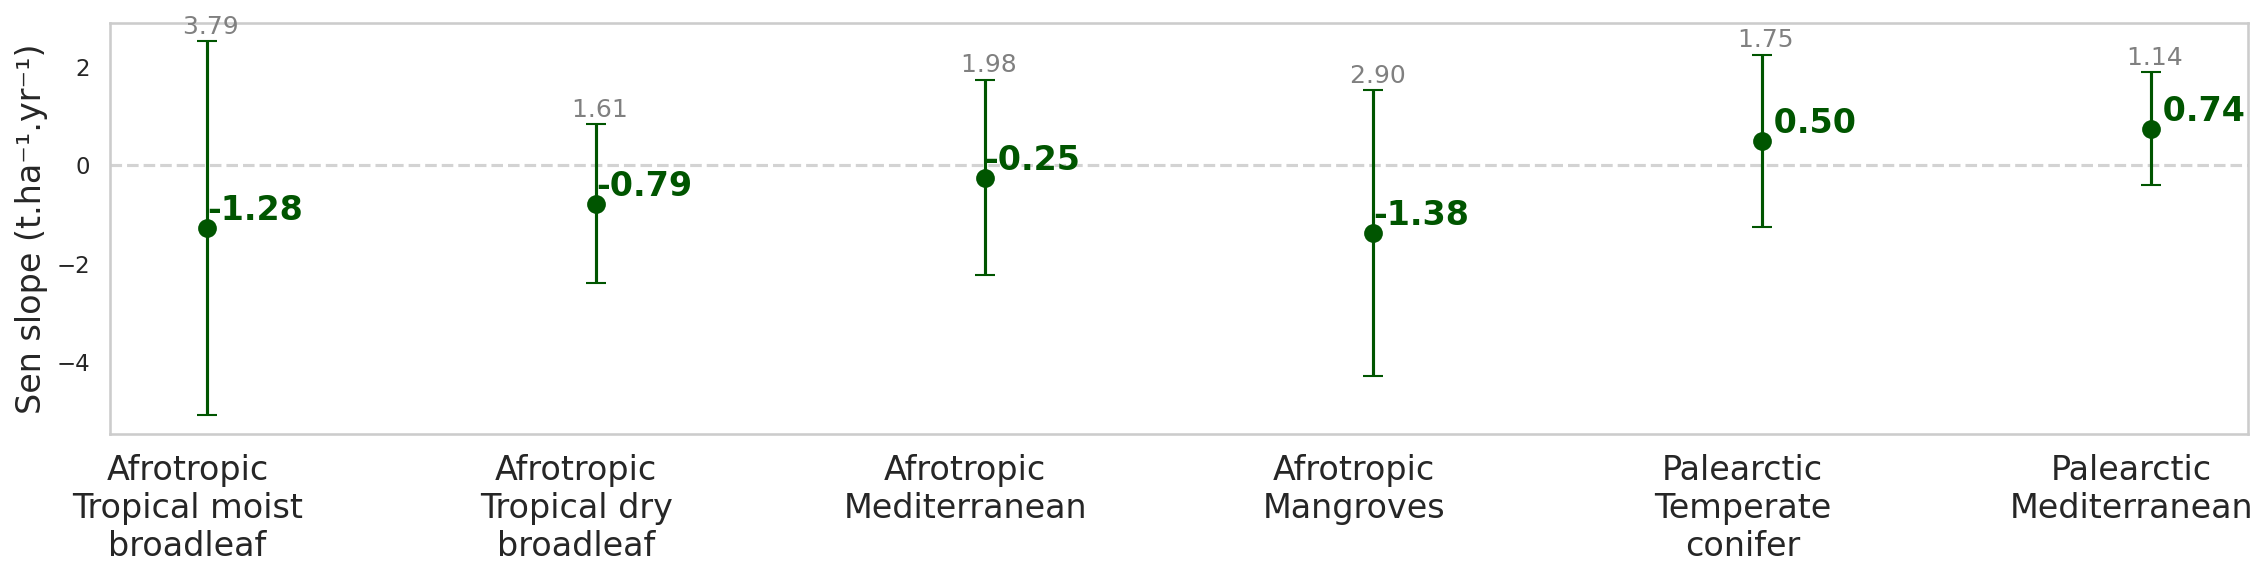

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(18, 4),dpi=150)#, dpi=300)

ax.axhline(0, color='lightgray', linewidth=1.5, linestyle='--', zorder=1)
df_plot_stats_filtered = df_plot_stats[df_plot_stats['ECO_BIOME_'].isin(ecobiomes)].dropna(subset=['MeanValue', 'StdDevValue'])


ecobiome_names_for_plot = df_plot_stats_filtered['Ecobiome_name'].unique().tolist()
x_positions = np.arange(len(ecobiome_names_for_plot))


variable_types = [#'Rate',
                  'Sen slope']
plot_colors = [#'#1f78b4',
               '#005500']

bar_width = 0.2

for i, var_type in enumerate(variable_types):
    subset = df_plot_stats_filtered[df_plot_stats_filtered['Variable'] == var_type]

    subset = subset.set_index('Ecobiome_name').reindex(ecobiome_names_for_plot).reset_index()

    offset = (i - (len(variable_types) - 1) / 2) * bar_width + 0.05

    ax.errorbar(
        x_positions + offset,
        subset['MeanValue'],
        yerr=subset['StdDevValue'],
        fmt='o',
        capsize=5,
        color=plot_colors[i],
        label=var_type,
        markersize=8,
        elinewidth=1.5
    )

    for j, (_, row) in enumerate(subset.iterrows()):
        if not pd.isna(row['MeanValue']):
            ax.text(
                x_positions[j] + offset ,
                row['MeanValue'] + 0.02,
                f'{row["MeanValue"]: .2f}',
                ha='left',
                va='bottom',
                fontsize=16,
                color=plot_colors[i],
                fontweight='bold'
            )

            ax.text(
                x_positions[j] + offset,
                row['MeanValue'] + row['StdDevValue'] + 0.05,
                f'{row["StdDevValue"]: .2f}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='gray'
            )

ax.set_xticks(x_positions)
ax.set_xticklabels([textwrap.fill(m, width=15) for m in ecobiome_names_for_plot], rotation=0, ha='center', fontsize=16)
#ax.set_title('Mean (+/- SD) of Annual Change Metrics (2015-2021) by EcoBiome', fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('Sen slope (t.ha⁻¹.yr⁻¹)', fontsize=16)
#ax.legend(title='', loc='lower right',frameon=False)

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.grid(False)
plt.show()

In [ ]:
stratum = 'forestEcobiomes'
variable = 'AnnualAGBChangeAreas'
stat_name = 'sums'
prefix = variable+ '_' + stat_name + '_' + stratum + '_'
suffix = '_changeThreshold_0_01_'+res+'m'

folder_path_strat = folder_path + stratum
all_files_strat = [f for f in os.listdir(folder_path_strat) if os.path.isfile(os.path.join(folder_path_strat, f))]
filtered_file = [f for f in all_files_strat if prefix in f]
csv_files = [f for f in filtered_file if f.lower().endswith('.csv')]
csv_file_paths = [os.path.join(folder_path_strat, f) for f in csv_files]
csv_file_paths

dfs = []
for f in csv_file_paths:
    stem = Path(f).stem  # remove .csv
    mask = stem.removeprefix(prefix).removesuffix(suffix)
    temp = pd.read_csv(f)
    temp["Mask"] = mask
    dfs.append(temp)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=["system:index", '.geo'])


mask_name_mapping = {
                      #'landmask': 'Land',
                      'GLCLUforests_2015': "Trees 2015 >5m (GLCLU)",
                      #'GLCLUshortVeg_2015':"Short vegetation 2015 <5m (GLCLU)",
                      # "FCSwoody2005": "Woody 2005 (FCS)",
                      # "FCSforest2005": "Forests 2005 (FCS)",
                      # "canopy_10pc_2005": "Canopy >10% 2005 (NASA)",
                      # 'lowFragmentation2020': 'Non-fragmented 2020',
                      # 'highFragmentation2020': 'Fragmented 2020',
                      # 'plantations2021':'Plantations 2021',
                      # 'plantations2015':'Plantations 2015',
                      # 'agroforestry2015': 'Agroforestry 2015',
                      # 'managed2015': 'Managed 2015',
                      # "ifl2025":"Intact forests 2025",
                      # 'nonifl2025':"Non-intact forests 2025",
                      # 'fire': 'Fire',
                      # 'nonFire': 'Non-fire',
                      # 'deforested': 'Deforested',
                      # 'regrowing': 'Regrowing'
}
df['Mask'] = df['Mask'].replace(mask_name_mapping)
df['Biome'] = df['ECO_BIOME_'].str[-2:]
df['Realm'] = df['ECO_BIOME_'].str[:2]
df['Biome_name'] = df['ECO_BIOME_'].str[-2:].map(biome_dic)
df['Realm_name'] = df['ECO_BIOME_'].str[:2].map(realm_dic)
df['Ecobiome_name'] = df['Realm_name']  + ' ' + df['Biome_name']
df = df.T.reset_index()
df.columns = df.iloc[16]#16
#df = df[:11]
df = df.drop([0, 11, 12, 13, 14, 15,16])
df_areas = df
df_areas

ValueError: No objects to concatenate

In [ ]:
ecobiomes = ['Afrotropic Tropical moist broadleaf',	'Afrotropic Tropical dry broadleaf',	'Afrotropic Mediterranean',	'Afrotropic Mangroves',
             #'Indomalay Mangroves',	'Palearctic Temperate broadleaf & mixed',
             'Palearctic Temperate conifer',	'Palearctic Mediterranean']


In [ ]:
df_areas['Variable'] = df_areas['Ecobiome_name']
df_areas['Variable'] = df_areas['Variable'].apply(lambda x: x.split('_')[0])
var_name_mapping = {
    'senSlope': 'Sen slope',
    'rate': 'Rate',
    'shifts': 'Shifting',
    'unidirectionalSenSlope': 'Unidirectional',
    'decGain': 'Decelerating (or reversing)',
    'decLoss': 'Decelerating (or reversing)',
    'accGain': 'Accelerating',
    'accLoss': 'Accelerating'
}
df_areas['Variable'] = df_areas['Variable'].replace(var_name_mapping)


def get_direction(mask_name):
    if 'gain_Area_Mha' in mask_name:
        return 'Gain'
    elif 'loss_Area_Mha' in mask_name:
        return 'Loss'
    elif 'Loss_Area_Mha' in mask_name:
        return 'Loss'
    elif 'Gain_Area_Mha' in mask_name:
        return 'Gain'
    return np.nan
df_areas['Direction'] = df_areas['Ecobiome_name']
df_areas['Direction'] = df_areas['Direction'].apply(get_direction)
df_areas

In [ ]:
annChangeVar = ['Rate',  'Sen slope']
df_areas_annChangeVar = df_areas[df_areas['Variable'].isin(annChangeVar)]

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        absolute = pct/100.*total
        return f'{pct:.2f}%\n({absolute:.2f} Mha)'
    return my_autopct


fig, axes = plt.subplots(len(annChangeVar), len(ecobiomes), figsize=(20, 8))

colors = ['#C5E0B4', '#D6BBEB']


for var_idx, var in enumerate(annChangeVar):

    for mask_idx, mask_col in enumerate(ecobiomes):
        ax = axes[var_idx, mask_idx]

        gain_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Gain')]
        loss_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Loss')]

        gain_value = gain_row[mask_col].values[0] if not gain_row.empty else 0
        loss_value = loss_row[mask_col].values[0] if not loss_row.empty else 0

        data = [gain_value, loss_value]

        if sum(data) > 0:
            ax.pie(data, autopct=make_autopct(data), startangle=90, colors=colors, textprops={'fontsize': 12})
            ax.axis('equal')
        else:
            ax.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')


        if var_idx == 0:
            wrapped_title = textwrap.fill(mask_col, width=20)
            ax.set_title(wrapped_title, fontsize=14, fontweight='bold')


    y_pos = (1 - (var_idx + 0.5) / len(annChangeVar))
    fig.text(0.03, y_pos, var, ha='center', va='center', rotation='vertical', fontsize=18, fontweight='bold')
legend_elements = [Patch(facecolor=colors[0], label='Gain (>0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)'),
                   Patch(facecolor=colors[1], label='Loss (<-0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)')]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           fancybox=True, shadow=False, ncol=2, fontsize=16,frameon=False)

plt.tight_layout(rect=[0.05, 0, 1, 0.95]) # [left, bottom, right, top]
plt.show()

In [ ]:
annChangeVar = ['Unidirectional','Shifting']
df_areas_annChangeVar = df_areas[df_areas['Variable'].isin(annChangeVar)].copy()

fig, axes = plt.subplots(1, len(ecobiomes), figsize=(5 * len(ecobiomes),5))

colors = ['#C5E0B4', '#D6BBEB']

for mask_idx, mask_col in enumerate(ecobiomes):

    if len(ecobiomes) == 1:
        ax = axes
    else:
        ax = axes[mask_idx]

    gain_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == 'Unidirectional')]
    loss_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == 'Shifting')]

    gain_value = gain_row[mask_col].values[0] if not gain_row.empty else 0
    loss_value = loss_row[mask_col].values[0] if not loss_row.empty else 0

    data = [gain_value, loss_value]

    ax.pie(data, autopct=make_autopct(data), startangle=90, colors=colors, textprops={'fontsize': 12})
    ax.axis('equal')
    wrapped_title = textwrap.fill(mask_col, width=20)
    ax.set_title(wrapped_title, fontsize=14, fontweight='bold')

legend_elements = [Patch(facecolor=colors[0], label='Unidirectional', ),
                   Patch(facecolor=colors[1], label='Shifting')]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.07), fancybox=True, shadow=False, ncol=2, fontsize=16,frameon=False)

fig.suptitle('Shifting vs unidirectional changes', fontsize=25, y=1.1)

plt.tight_layout(rect=[0, 0, 1, 0.2]) # [left, bottom, right, top]
plt.show()

In [ ]:
annChangeVar = ['Accelerating','Decelerating (or reversing)'] #
df_areas_annChangeVar = df_areas[df_areas['Variable'].isin(annChangeVar)].copy()


fig, axes = plt.subplots(len(annChangeVar), len(ecobiomes), figsize=(20, 8))

colors = ['#C5E0B4', '#D6BBEB']


for var_idx, var in enumerate(annChangeVar):

    for mask_idx, mask_col in enumerate(ecobiomes):
        ax = axes[var_idx, mask_idx]

        gain_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Gain')]
        loss_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Loss')]

        gain_value = gain_row[mask_col].values[0] if not gain_row.empty else 0
        loss_value = loss_row[mask_col].values[0] if not loss_row.empty else 0

        data = [gain_value, loss_value]

        if sum(data) > 0:
            ax.pie(data, autopct=make_autopct(data), startangle=90, colors=colors, textprops={'fontsize': 12})
            ax.axis('equal')
        else:
            ax.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')


        if var_idx == 0:
            wrapped_title = textwrap.fill(mask_col, width=20)
            ax.set_title(wrapped_title, fontsize=14, fontweight='bold')


    y_pos = (1 - (var_idx + 0.5) / len(annChangeVar))
    fig.text(0.03, y_pos, var, ha='center', va='center', rotation='vertical', fontsize=18, fontweight='bold')
legend_elements = [Patch(facecolor=colors[0], label='Gain (>0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)'),
                   Patch(facecolor=colors[1], label='Loss (<-0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)')]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           fancybox=True, shadow=False, ncol=2, fontsize=16,frameon=False)

plt.tight_layout(rect=[0.05, 0, 1, 0.95]) # [left, bottom, right, top]
plt.show()

In [ ]:
biomes = gpd.read_file('/content/drive/MyDrive/Ecoregions2017/Ecoregions2017.shp')
biomes['color'] = biomes['BIOME_NUM'].astype(int).astype(str).str.zfill(2).map(color_map)
biomes

# 7- Map ecoBiomes

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor='lightgrey')
ax.add_feature(cfeature.LAKES, facecolor='white')
#ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)

biomes.plot(ax=ax, edgecolor='none', linewidth=0, transform=ccrs.PlateCarree(), color=biomes['COLOR_BIO'], alpha=0.7, legend = True)

ax.set_title('Biomes', fontsize=14)
ax.set_extent(ext, crs=ccrs.PlateCarree())

#scalebar = ScaleBar(1, units = 'deg', dimension="angle", fixed_value=1000, fixed_units='km', location='lower left')#, length_fraction=0.07)  # res m per pixel
#ax.add_artist(scalebar)
#north_arrow(ax=ax, location="lower left", rotation={"crs":3857, "reference":"center"})

# legend_entries = biomes.drop_duplicates(subset=['BIOME_NAME', 'COLOR_BIO']).sort_values(by='BIOME_NAME')

# legend_handles = [
#     mpatches.Patch(color=row['COLOR_BIO'], label=row['BIOME_NAME'], alpha=0.7)
#     for _, row in legend_entries.iterrows()
# ]
# plt.legend(handles=legend_handles, loc='right', frameon=False, bbox_to_anchor=(1.52, 0.5))#bbox_to_anchor=(1.05, 1))#, bbox_to_anchor=(0.5, -0.1))# bbox_to_anchor=(1.05, 1))# title='Biomes',  loc='upper center', borderaxespad=0., )

ax.set_axis_off()
plt.show()

In [ ]:
forestEcobiomes = ee.FeatureCollection('projects/ee-nacil/assets/Ecoregions/EcoBiomes').filterBounds(g).filter(ee.Filter.inList('ECO_BIOME_', ecobiomes)).select(['ECO_BIOME_'])


In [ ]:
# ecobiome_name_mapping = {
#     'AF01': 'Afrotropic Tropical moist broadleaf',
#     'AF02': 'Afrotropic Tropical dry broadleaf',
#     'AF12': 'Afrotropic Mediterranean',
#     'AF14': 'Afrotropic Mangroves',
#     'PA05': 'Palearctic Temperate conifer',
#     'PA12': 'Palearctic Mediterranean'
# }
# ecobiomes = [#'AF01'#,
#              #'AF02',
#              #'AF12',
#              #'AF14',
#              #'PA05',
#              'PA12'
#              ]
# for ecobiome_code in ecobiomes:
#   current_ecobiome_ee = forestEcobiomes.filter(ee.Filter.eq('ECO_BIOME_', ecobiome_code))
#   current_ecobiome_gdf = geemap.ee_to_gdf(current_ecobiome_ee)
#   fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
#   ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=0)
#   current_ecobiome_gdf.plot(ax=ax, facecolor='black', edgecolor='black', linewidth=1, transform=ccrs.PlateCarree(), zorder=1)
#   #ax.set_title(ecobiome_name_mapping.get(ecobiome_code, ecobiome_code), fontsize=20)
#   ax.set_extent(ext, crs=ccrs.PlateCarree())
#   ax.set_frame_on(False)
#   ax.set_xticks([])
#   ax.set_yticks([])
#   plt.show()
# #'#606060'

In [ ]:
# annChangeVar = ['Accelerating (hotspots)','Decelerating (or reversing)'] #
# df_areas_annChangeVar = df_areas[df_areas['Variable'].isin(annChangeVar)].copy()


# def make_autopct(values):
#     def my_autopct(pct):
#         total = sum(values)
#         absolute = int(round(pct/100.*total))
#         return f'{pct:.1f}% ({absolute:,.0f} Mha)'
#     return my_autopct


# fig, axes = plt.subplots(len(annChangeVar), len(masks), figsize=(20, 8))

# colors = ['#C5E0B4', '#D6BBEB', 'darkgray']

# for var_idx, var in enumerate(annChangeVar):

#     for mask_idx, mask_col in enumerate(masks):
#         ax = axes[var_idx, mask_idx]

#         gain_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Gain')]
#         loss_row = df_areas_annChangeVar[(df_areas_annChangeVar['Variable'] == var) & (df_areas_annChangeVar['Direction'] == 'Loss')]

#         gain_value = gain_row[mask_col].values[0] if not gain_row.empty else 0
#         loss_value = loss_row[mask_col].values[0] if not loss_row.empty else 0

#         total_area_value = df_maskAreas[mask_col].values[0]
#         change_value = gain_value + loss_value
#         no_change_value = total_area_value - change_value

#         data = [gain_value, loss_value, no_change_value]

#         if sum(data) > 0:
#             explode = [0.2 if v < 200 else 0 for v in data] # Explode only small slices
#             ax.pie(data, autopct=make_autopct(data), startangle=0, colors=colors, explode = explode, pctdistance=0.6, textprops={'fontsize': 10.5})#labeldistance=0.5,
#             ax.axis('equal')
#         else:
#             ax.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')


#         if var_idx == 0:
#             ax.set_title(mask_col, fontsize=14, fontweight='bold')


#     y_pos = (1 - (var_idx + 0.5) / len(annChangeVar))
#     wrapped_var = textwrap.fill(var , width=20)
#     fig.text(0.03, y_pos, wrapped_var, ha='center', va='center', rotation='vertical', fontsize=18, fontweight='bold')

# legend_elements = [Patch(facecolor=colors[0], label='Gain (>0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)'),
#                    Patch(facecolor=colors[1], label='Loss (<-0.01 t.ha\u207b\u00b9.yr\u207b\u00b9)'),
#                    Patch(facecolor=colors[2], label='Other')]

# fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
#            fancybox=True, shadow=False, ncol=3, fontsize=16,frameon=False)

# plt.tight_layout(rect=[0.05, 0, 1, 0.95]) # [left, bottom, right, top]
# plt.show()

In [ ]:
# Interpoaltion
# imbefore = 0.21025570765944288#0.2442503957218286#0.41202847557055233
# imafter = 0.3108143953541624#0.3704195104850305
# ybefore= 2010
# yafter = 2016
# ycurrent= 2015

# imbefore + ((ycurrent - ybefore) * (imafter - imbefore) / (yafter - ybefore))